In [30]:
import numpy as np 
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import math            
import pickle                   
import os 
import gc
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
matplotlib.rcParams["figure.dpi"] = 150
from particle import PDGID

In [31]:
trackDir = '/home/mwells5/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb_copy_m/tl_with_moduleID_07_28_2026/'
pklPath = "/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/Data_Files/Data_Set_2026Feb/plots/dfOfTruth.pkl"
flp = 0

with open(pklPath, 'rb') as file:
    # Reconstruct the Python object
    parquetData = pickle.load(file)

print(f"Total # of clusters: {len(parquetData)}")
print(f"keys parquets {parquetData.keys()} ")
print(parquetData.head())

Total # of clusters: 3373743
keys parquets Index(['x-entry', 'y-entry', 'z-entry', 'n_x', 'n_y', 'n_z', 'number_eh_pairs',
       'y-local', 'z-global', 'pt', 'hit_time', 'PID', 'cotAlpha', 'cotBeta',
       'y-midplane', 'x-midplane', 'adjusted_hit_time',
       'adjusted_hit_time_30ps_gaussian', 'adjusted_hit_time_60ps_gaussian',
       'source', 'eta', 'R', 'q', 'm', 'scalePion', 'p_calc1', 'p_calc2',
       'p_calc3', 'betaGamma', 'pathLength', 'EHperMicron'],
      dtype='object') 
     x-entry    y-entry  z-entry        n_x       n_y        n_z  \
0  -0.089798   7.854234      0.0  27.838490 -2.453614  72.915710   
1  -0.377802   4.397584      0.0 -20.095140 -8.864730  52.594067   
2 -60.413685  -0.862046      0.0  54.137943 -0.872323  26.676561   
3 -55.560413  29.759911      0.0  21.760685 -3.897908  22.761509   
4   5.722350   8.097929      0.0 -49.786995 -8.955063  68.700142   

   number_eh_pairs  y-local   z-global         pt  ...             R    q  \
0           3493.0   -

In [95]:
trackData = pd.DataFrame()
trackdata_list = []

trackHeader = ["cota", "cotb", "p", "flp", "ylocal", "zglobal", "pt", "t", "hit_pdg", "moduleID"]

countmm=0
countmp=0
for file in os.listdir(trackDir):
    if "bib_mm" in file:
        trackdata_list.append(pd.read_csv(f"{trackDir}{file}", sep=' ', names=trackHeader))
        countmm+=1 
    elif "bib_mp" in file: 
        trackdata_list.append(pd.read_csv(f"{trackDir}{file}", sep=' ', names=trackHeader))
        countmp+=1
    if countmp+countmm==10000:
        break 

trackData = pd.concat(trackdata_list)
del trackdata_list
gc.collect()

trackData['adjusted_hit_time'] = trackData['t']-1e6*np.sqrt(trackData['zglobal']**2+30**2)/299792458

print(f"length of tracklist {len(trackData)}")
print(f"tracklist keys {trackData.keys()}")

trackData = trackData[(trackData['zglobal'] >= 0) & (trackData['zglobal'] <= 13)]
trackData = trackData[(trackData['adjusted_hit_time'] >= -.09) & (trackData['adjusted_hit_time'] <= .15)]
#trackData = trackData[(trackData['moduleID'] == 4)]

parquetData = parquetData[(parquetData['z-global'] >= 0) & (parquetData['z-global'] <= 13)]
parquetData = parquetData[(parquetData['adjusted_hit_time'] >= -.09) & (parquetData['adjusted_hit_time'] <= .15)]

trackData.reset_index()

print((trackData.shape[0]))
print((parquetData.shape[0]))
print(trackData.head())
print(trackData['pt'].min())
print(trackData['pt'].max())
print(parquetData['pt'].min())
print(parquetData['pt'].max())

length of tracklist 1731437
tracklist keys Index(['cota', 'cotb', 'p', 'flp', 'ylocal', 'zglobal', 'pt', 't', 'hit_pdg',
       'moduleID', 'adjusted_hit_time'],
      dtype='object')
28453
332805
        cota     cotb        p  flp  ylocal  zglobal       pt        t  \
17   0.56304  0.25952  0.00132    0   1.575    1.600  0.00116  0.07822   
18  -0.56978 -0.49204  0.00130    0   3.075    0.200  0.00115  0.09027   
391  0.74492  0.37231  0.00226    0  -0.575   11.925  0.00185  0.10686   
392 -0.13254  0.40098  0.00152    0   1.700    8.500  0.00151  0.12643   
393 -1.06940 -0.93580  0.00213    0   0.100   12.750  0.00168  0.14934   

     hit_pdg  moduleID  adjusted_hit_time  
17        11         7          -0.021991  
18        11         7          -0.009801  
391       11         3          -0.000825  
392       11         3           0.022422  
393       11         3           0.040608  
5e-05
0.4434
5e-05
99.988983


In [27]:
def cut_tracks(df):
    df = df[(df['zglobal'] >= 0) & (df['zglobal'] <= 13)]
    df = df[(df['adjusted_hit_time'] >= -.09) & (df['adjusted_hit_time'] <= .15)]
    df = df[(df['moduleID'] == 1)]
    df.reset_index()
    return df

In [13]:
def percent_nonempty_pixels(mod_array):
    count = 0
    count = np.sum((mod_array != 0))
    count = int(10000 * count / len(mod_array)**2) / 100
    return count


In [36]:
def pixelAV_data_reduction(tracks, parquets):
    return math.trunc(1e5*((tracks.shape[0])-(parquets.shape[0]))/tracks.shape[0])/100

print(pixelAV_data_reduction(trackData, parquetData))

-948.52


In [92]:
def make_scatterplot_t(tracks_df):

    #cut_tracks(tracks_df)
    
    x_l = (tracks_df['zglobal']%13)*40 # 1mm = 40px
    x_l = x_l.to_numpy()
    x_l = x_l.astype(int)
    
    y_l = (((tracks_df['ylocal'])+8.5)*40)-160 # changes range from 0 to 13 and convert to px
    y_l = y_l.to_numpy()
    y_l = y_l.astype(int)

    momenta = tracks_df['p']
    momenta = momenta.to_numpy()

    hit_min = math.trunc(tracks_df['adjusted_hit_time'].min()*100)/100
    hit_max = math.trunc(tracks_df['adjusted_hit_time'].max()*100)/100

    if (tracks_df['moduleID'].max() == tracks_df['moduleID'].min()):
        number = tracks_df['moduleID'].iat[0]
    else:
        number = 'N/A'


    fig, ax = plt.subplots(figsize=(7,7),dpi=200)
    im = ax.scatter(x_l, y_l, c=momenta, cmap='Reds', norm=mcolors.LogNorm(vmin=1e-5, vmax=100), marker='.')

    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    fig.colorbar(im, cax=cax, location='right',label='momentum [GeV]')
    ax.set_title(f"Scatterplot from tracks, module {number}")
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    fig.colorbar(im, cax=cax, location='right',label='momentum [GeV]')

    ax.set_xlim(0,520)
    ax.set_ylim(0,520)
    ax.set_xlabel("x-local [px]")
    ax.set_ylabel("y-local [px]")
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(40))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(40))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(20))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(20))
    plt.figtext(0.163,0.15, f"Number of hits: {tracks_df.shape[0]}\n{hit_min} > Adj. hit time > {hit_max}", fontsize=12, 
                bbox=dict(facecolor='white', alpha=0.8))
    plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
        
    plt.tight_layout(pad=3.5)
    fig.canvas.draw()

def make_scatterplot_p(parquets_df):

    #cut_tracks(tracks_df)
    
    x_l = (parquets_df['z-global']%13)*40 # 1mm = 40px
    x_l = x_l.to_numpy()
    x_l = x_l.astype(int)
    
    y_l = (((parquets_df['y-local'])+8.5)*40) # changes range from 0 to 13 and convert to px
    y_l = y_l.to_numpy()
    y_l = y_l.astype(int)

    momenta = parquets_df['p_calc1']
    momenta = momenta.to_numpy()
    #print(momenta.max)

    hit_min = math.trunc(parquets_df['adjusted_hit_time'].min()*100)/100
    hit_max = math.trunc(parquets_df['adjusted_hit_time'].max()*100)/100

    fig, ax = plt.subplots(figsize=(7,7),dpi=200)
    im = ax.scatter(x_l, y_l, c=momenta, cmap='Blues', norm=mcolors.LogNorm(vmin=1e-5, vmax=100), marker='.')

    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    fig.colorbar(im, cax=cax, location='right',label='momentum [GeV]')
    ax.set_title(f"Scatterplot from parquets")
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    fig.colorbar(im, cax=cax, location='right',label='momentum [GeV]')

    ax.set_xlim(0,520)
    ax.set_ylim(0,520)
    ax.set_xlabel("x-local [px]")
    ax.set_ylabel("y-local [px]")
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(40))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(40))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(20))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(20))
    plt.figtext(0.163,0.15, f"Number of hits: {parquets_df.shape[0]}\n{hit_min} > Adj. hit time > {hit_max}", fontsize=12, 
                bbox=dict(facecolor='white', alpha=0.8))
    plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
        
    plt.tight_layout(pad=3.5)
    fig.canvas.draw()



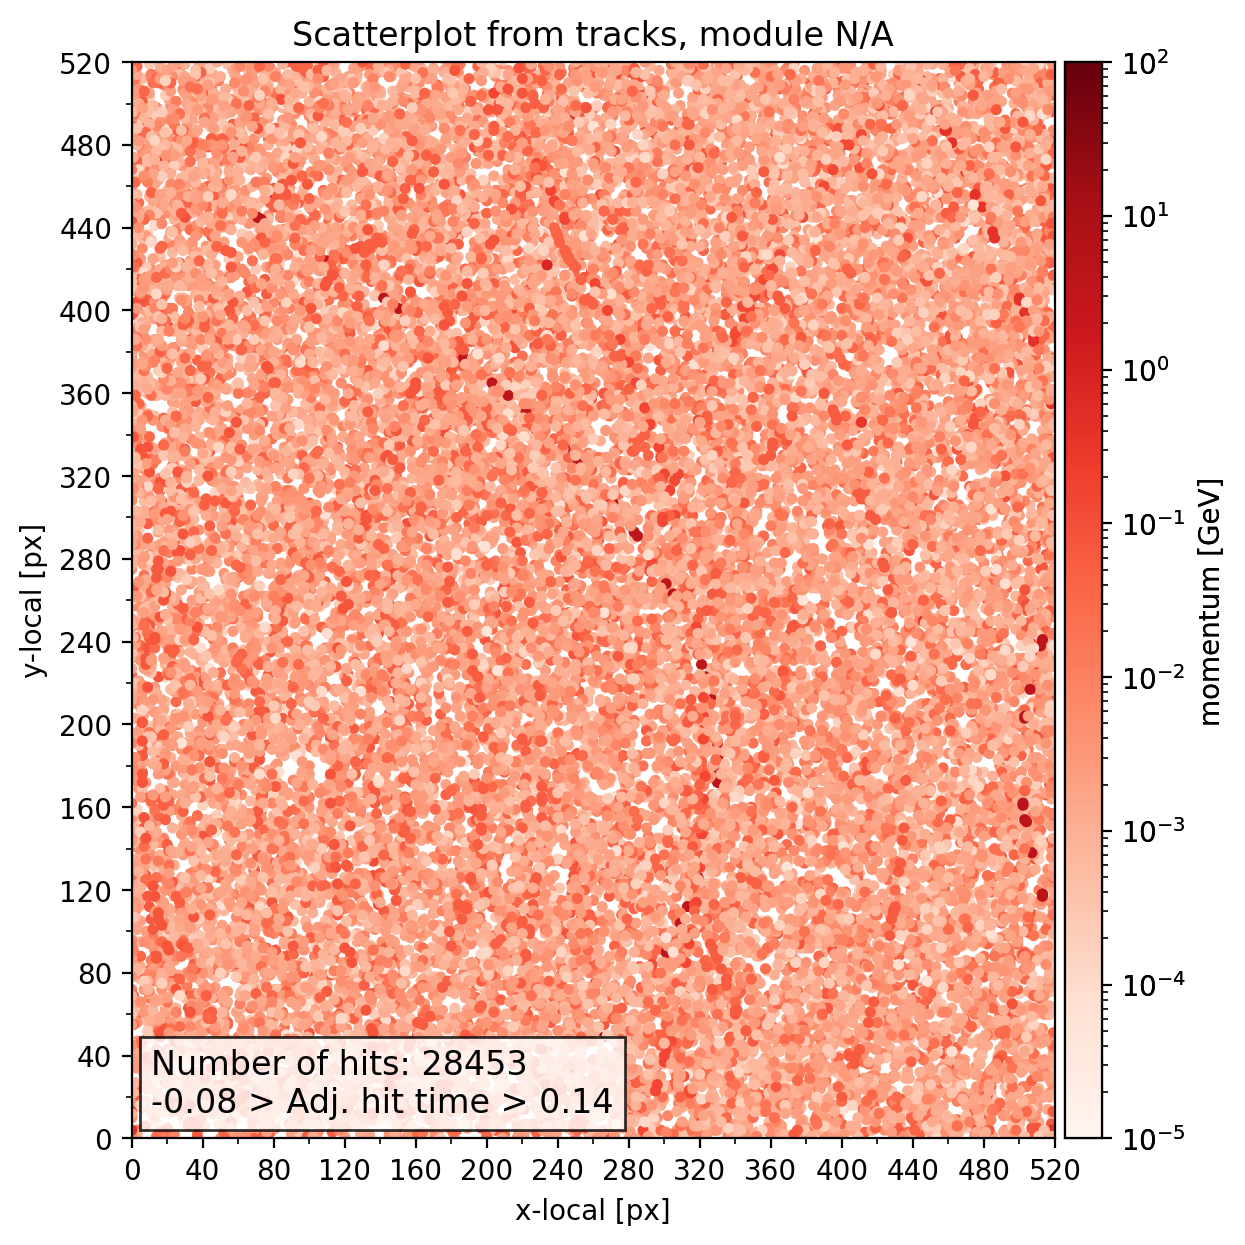

In [96]:
make_scatterplot_t(trackData)

# max time for all tracks = 50.5 seconds


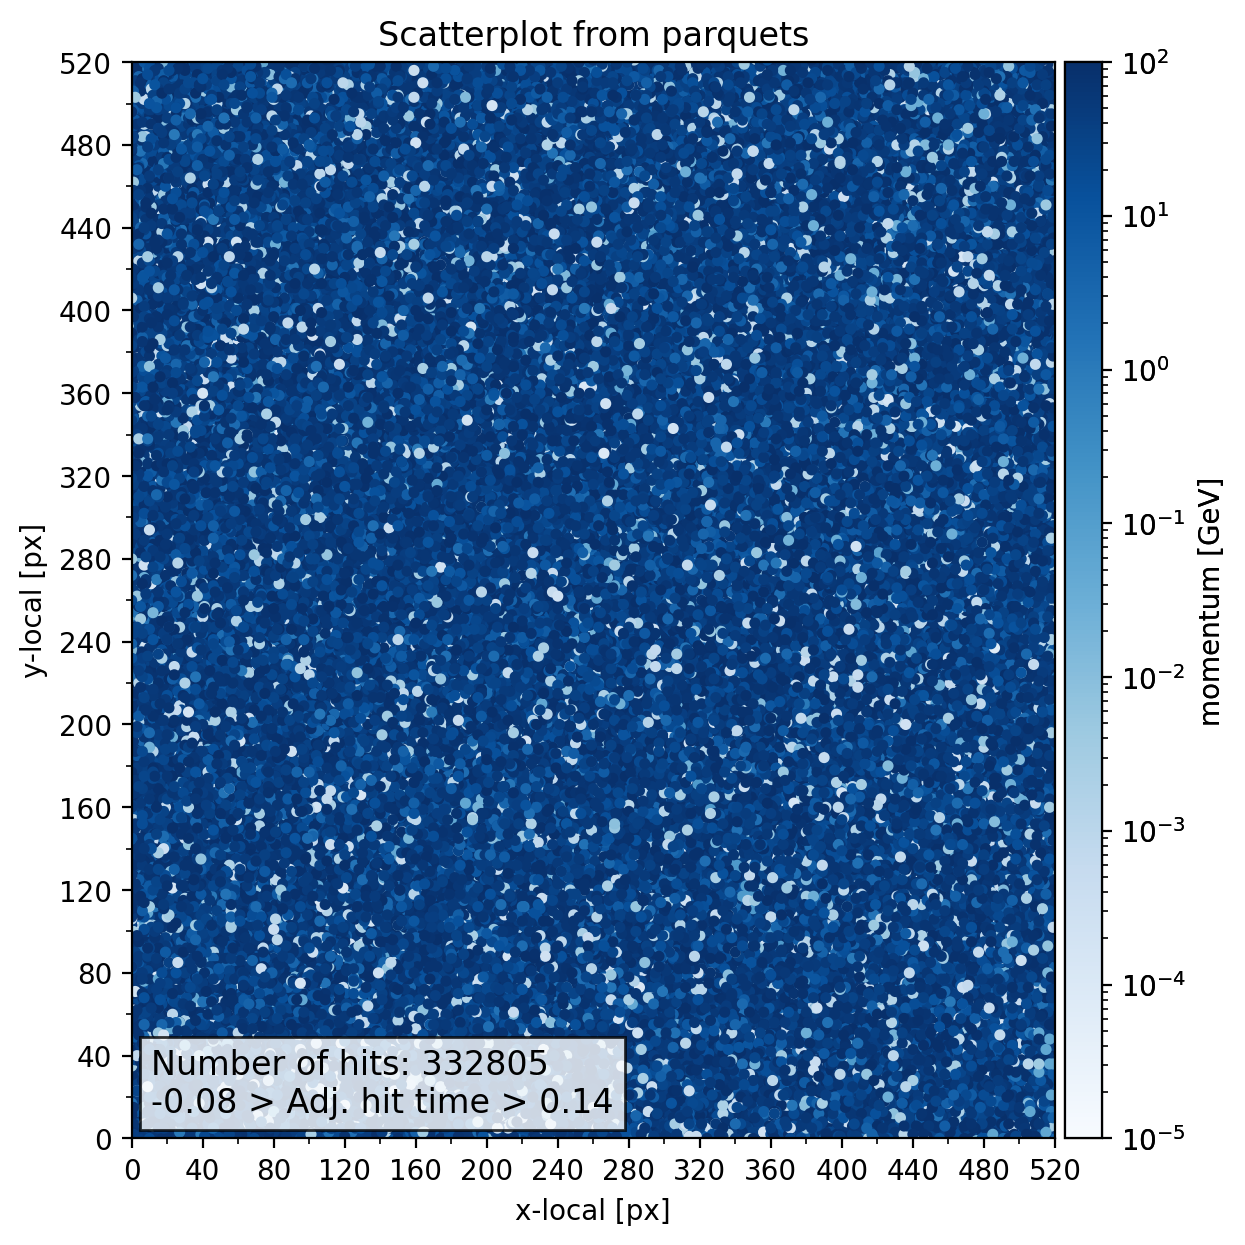

In [94]:
make_scatterplot_p(parquetData)

# max time for all events = 100 seconds